# Fine-tune an LLM with Differential Privacy

This notebook fine-tunes DistilGPT-2 on AG News using LoRA adapters
with DP-SGD. It exercises the full production workflow: adaptive
clipping, truncated Poisson sampling, microbatching, and DP-aware optimization.

**Prerequisites:** [DP-SGD Training](dp_sgd_training.ipynb),
[Sampling & Microbatching](sampling_and_microbatching.ipynb).

**Components exercised:** `make_functional` with `partition_trainable`,
`adaptive_clipped_grad`, `PoissonSampler`, `opake.optimizers.adamw` (DP-aware bias correction),
`dpsgd_acc.poisson` (truncated form), PEFT LoRA.
**Runtime:** ~2 minutes on CPU.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchopt
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForCausalLM, AutoTokenizer

import opake.accounting as acc
import opake.dpsgd.accounting as dpsgd_acc
from opake.dpsgd.noise import gaussian_noise
from opake.dpsgd.sampling import PoissonSampler
from opake.functional import make_functional
from opake.optimizers import adamw
from opake.dpsgd.clipping import adaptive_clipped_grad
from opake.patches import apply_model_patches, apply_runtime_patches
from opake.random import key

torch.manual_seed(42)
np.random.seed(42)

## Configuration

In [2]:
MODEL_NAME = "distilgpt2"
LORA_R = 8
LORA_ALPHA = 16

NUM_STEPS = 20
BATCH_SIZE = 8
MAX_BATCH_SIZE = 12
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.01
MICROBATCH_SIZE = 4
MAX_LENGTH = 64

CLIP_NORM = 0.1
NOISE_MULTIPLIER = 1.5
TARGET_DELTA = 1e-5

LOG_INTERVAL = 5

## Load model and apply LoRA

LoRA reduces the number of trainable parameters to ~0.5% of the full
model, which keeps per-example gradient norms small and makes clipping
more effective.

In [3]:
apply_runtime_patches()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    target_modules=["c_attn", "c_proj"],
)
model = get_peft_model(model, lora_config)

# Wire vmap-safe attention/RMS/PEFT kernels into this model instance.
apply_model_patches(model)

model.print_trainable_parameters()

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 405,504 || all params: 82,318,080 || trainable%: 0.4926


/workspace/.venv/lib/python3.12/site-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## Prepare dataset

In [4]:
dataset = load_dataset("fancyzhx/ag_news", split="train")
# Subsample for tutorial speed (full set is 120k; the workflow is identical at scale).
texts = [ex["text"] for ex in dataset.select(range(500))]

tokenized = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt",
)

input_ids = tokenized["input_ids"]
attention_mask = tokenized["attention_mask"]
labels = input_ids.clone()
train_dataset = TensorDataset(input_ids, attention_mask, labels)

print(f"Dataset: {len(train_dataset)} examples, sequence length {MAX_LENGTH}")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset: 500 examples, sequence length 64


## Functional conversion and loss function

`partition_trainable=True` separates the LoRA weights (trainable) from
the frozen base model, so only the LoRA gradients are clipped and
noised.

In [5]:
fmodel, trainable_params, frozen_params = make_functional(
    model,
    disable_autograd_tracking=True,
    partition_trainable=True,
)

trainable_count = sum(p.numel() for p in trainable_params.values())
frozen_count = sum(p.numel() for p in frozen_params.values())
print(f"Trainable: {trainable_count:,}  Frozen: {frozen_count:,}")


def per_example_loss(trainable, frozen, ids, mask, labels):
    all_params = {**frozen, **trainable}
    out = fmodel(
        all_params,
        ids.unsqueeze(0),
        attention_mask=mask.unsqueeze(0),
        labels=labels.unsqueeze(0),
    )
    return out.loss

Trainable: 405,504  Frozen: 81,912,576


## Sampler, clipping, noise, and optimizer

In [6]:
sample_rate = BATCH_SIZE / len(train_dataset)
FRACTION_NOISE_STD = 0.05  # adaptive_clipped_grad default; must match adaclip()

sampler = PoissonSampler(
    train_dataset,
    sample_rate=sample_rate,
    truncated_batch_size=MAX_BATCH_SIZE,
    n_steps=NUM_STEPS,
    key=key(42),
)
train_loader = DataLoader(train_dataset, batch_sampler=sampler)

grad_fn, clip_state = adaptive_clipped_grad(
    per_example_loss,
    argnums=0,
    batch_argnums=(2, 3, 4),
    initial_clipping_norm=CLIP_NORM,
    target_quantile=0.80,
    microbatch_size=MICROBATCH_SIZE,
    return_aux=True,
    clipping_norm_min=0.01,
    clipping_norm_max=10.0,
    fraction_noise_std=FRACTION_NOISE_STD,
    key=key(0),
    normalize_by=BATCH_SIZE,
)

noise_fn, noise_state = gaussian_noise(
    noise_multiplier=NOISE_MULTIPLIER,
    key=key(42),
)

optimizer = adamw(
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    noise_bias_correction=True,
)
opt_state = optimizer.init(trainable_params)

step_proc = dpsgd_acc.poisson(
    dpsgd_acc.adaclip(
        dpsgd_acc.gaussian(NOISE_MULTIPLIER),
        fraction_noise_std=FRACTION_NOISE_STD,
        expected_batch_size=BATCH_SIZE,
    ),
    sample_rate,
    truncated_batch_size=MAX_BATCH_SIZE,
    dataset_size=len(train_dataset),
)

# Pre-compute expected final epsilon
expected_eps = (step_proc * NUM_STEPS).epsilon_at(TARGET_DELTA)
print(f"Expected final epsilon: {expected_eps:.2f}")

Expected final epsilon: 8.99


## Training loop

In [7]:
losses = []
epsilons = []
clip_norms = []

for step, (batch_ids, batch_mask, batch_labels) in enumerate(train_loader):
    if step >= NUM_STEPS:
        break

    # 1. Clipped gradients (adaptive threshold, microbatched).
    #    `grads` is a ClippedPytree carrying the current per-step max_norm.
    (grads, aux), clip_state = grad_fn(
        trainable_params,
        frozen_params,
        batch_ids,
        batch_mask,
        batch_labels,
        state=clip_state,
    )

    # 2. Add noise (sensitivity is read from grads.max_norm).
    noisy_grads, noise_state = noise_fn(grads, noise_state)

    # 3. Optimizer step
    updates, opt_state = optimizer.update(
        noisy_grads,
        opt_state,
        params=trainable_params,
    )
    trainable_params = torchopt.apply_updates(trainable_params, updates)

    # 4. Track privacy
    dp_step = step_proc * (step + 1)
    epsilon = dp_step.epsilon_at(TARGET_DELTA)

    avg_loss = aux.loss_values.mean().item()
    losses.append(avg_loss)
    epsilons.append(epsilon)
    clip_norms.append(grads.max_norm)

    if (step + 1) % LOG_INTERVAL == 0 or step == 0:
        print(
            f"Step {step + 1:4d}/{NUM_STEPS}  "
            f"loss={avg_loss:.3f}  "
            f"clip={grads.max_norm:.3f}  "
            f"epsilon={epsilon:.2f}"
        )

print(f"\nFinal: loss={losses[-1]:.3f}, epsilon={epsilons[-1]:.2f}")
assert abs(epsilons[-1] - expected_eps) < 1e-9

/workspace/.venv/lib/python3.12/site-packages/transformers/integrations/sdpa_attention.py:158: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_flash_attention_for_cpu. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:82.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


/workspace/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:1072: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_flash_attention_for_cpu_backward. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:82.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Step    1/20  loss=5.246  clip=0.013  epsilon=6.04


Step    5/20  loss=6.465  clip=0.015  epsilon=7.61


Step   10/20  loss=6.611  clip=0.018  epsilon=8.27


Step   15/20  loss=5.687  clip=0.022  epsilon=8.68


Step   20/20  loss=6.278  clip=0.027  epsilon=8.99

Final: loss=6.278, epsilon=8.99


## Results

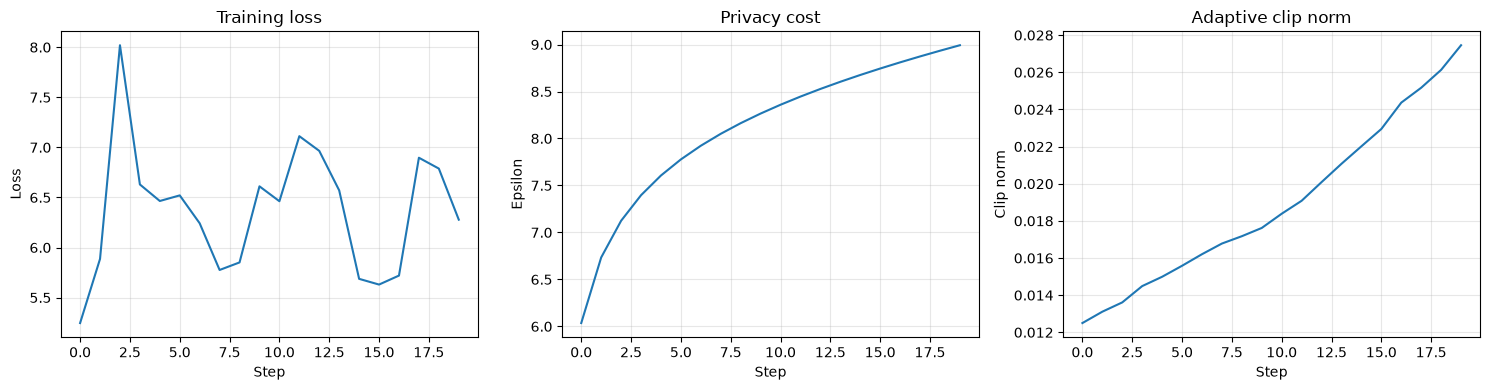

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(epsilons)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Epsilon")
axes[1].set_title("Privacy cost")
axes[1].grid(alpha=0.3)

axes[2].plot(clip_norms)
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Clip norm")
axes[2].set_title("Adaptive clip norm")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Key choices for LLM fine-tuning with DP:

- **LoRA** reduces trainable parameters to <1% of the model, keeping
  gradient norms small.
- **Adaptive clipping** (`adaptive_clipped_grad`) avoids manual tuning
  of the clip threshold.
- **Truncated Poisson sampling** bounds memory while preserving privacy
  amplification.
- **Microbatching** (`microbatch_size`) further reduces peak memory.
- **`partition_trainable`** ensures only LoRA weights are clipped and
  noised.

For hyperparameter guidance, see the
[HuggingFace Compatibility guide](../user-guide/huggingface/index.md).